# Fig. 1(c,d) from sources

| Data | Source | How obtained |
|---|---|---|
| TiO$_2$ enamel, before/after 891 sun-h UV | Leggett & King, AIAA 78-884 (1978), Fig. 6, [doi](https://doi.org/10.2514/6.1978-884) | digitized (below) |
| BaSO$_4$ paint | Li et al., ACS AMI 13, 21733 (2021), Fig. 2d, [doi](https://doi.org/10.1021/acsami.1c02368) | digitized (below) |
| Black HDPE | USGS Spectral Library v7, record *Plastic_HDPE GDS351 BlkSheet*, [doi](https://doi.org/10.5066/F7RR1WDJ) | measured spectrum, downloaded as numbers (file header names the record) |
| Sun, c-Si response | ASTM G173-03 AM1.5G and an example c-Si response, as tabulated in pvlib | `pvlib.spectrum.get_reference_spectra()`, `get_example_spectral_response()` |
| Gain line g0 + k·R | this project's ray trace, Fig. 2 (full deck, 0.40 m): R 0.05 → 1.384 %, R 0.70 → 15.497 % | [Fig. 2(b) notebook] |


### How the digitized curves were made
Points were placed on each published curve in WebPlotDigitizer after calibrating two known gridlines per axis; the tool exports the CSVs in `data/`. Screenshots of the digitizing (traced points over the original figures):

**Leggett & King (1978) Fig. 6** (red = before UV, blue = after UV):

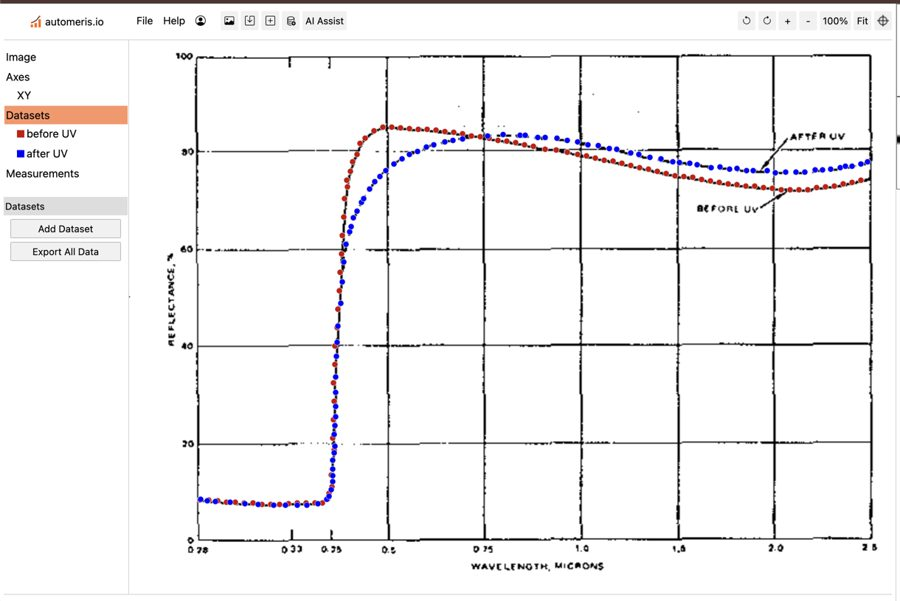

**Li et al. (2021) Fig. 2d** (blue = traced points on the paper's black curve):

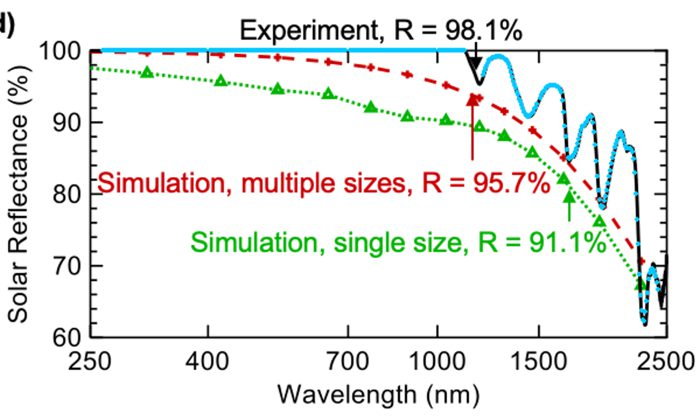

In [1]:
import os, urllib.request
os.makedirs("data", exist_ok=True)  # source data, fetched when run outside the repo (e.g. Colab)
for url in [
    "https://raw.githubusercontent.com/fpv-enamel/enamel-float-notebooks/main/fig1cd/data/splib07a_Wavelengths_ASD_0.35-2.5_microns_2151_ch.txt",
    "https://raw.githubusercontent.com/fpv-enamel/enamel-float-notebooks/main/fig1cd/data/splib07a_Plastic_HDPE_GDS351_BlkSheet_ASDFRa_AREF.txt",
    "https://raw.githubusercontent.com/fpv-enamel/enamel-float-notebooks/main/fig1cd/data/baso4_paint_li2021_fig2d_digitized_raw.csv",
    "https://raw.githubusercontent.com/fpv-enamel/enamel-float-notebooks/main/fig1cd/data/leggett_king_1978_fig6.png",
    "https://raw.githubusercontent.com/fpv-enamel/enamel-float-notebooks/main/fig1cd/data/leggett_king_1978_fig6_digitized.csv",
    "https://raw.githubusercontent.com/fpv-enamel/enamel-float-notebooks/main/fig1cd/data/leggett_king_1978_fig6_wpd_project.json",
    "https://raw.githubusercontent.com/fpv-enamel/enamel-float-notebooks/main/raytrace/results.csv",
]:
    f = "data/" + url.split("/")[-1]
    if not os.path.exists(f):
        urllib.request.urlretrieve(url, f)

import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
!pip -q install pvlib
import pvlib

wl = np.arange(350, 1201, 5)  # nm
D = "data/"

x = np.loadtxt(D + "splib07a_Wavelengths_ASD_0.35-2.5_microns_2151_ch.txt", skiprows=1) * 1000
y = np.loadtxt(D + "splib07a_Plastic_HDPE_GDS351_BlkSheet_ASDFRa_AREF.txt", skiprows=1)
r_black = np.interp(wl, x[y > 0], y[y > 0])

b = pd.read_csv(D + "baso4_paint_li2021_fig2d_digitized_raw.csv")
r_baso4 = np.interp(wl, b.wavelength_nm, b.reflectance)

sun = np.interp(wl, *pvlib.spectrum.get_reference_spectra()["global"].reset_index().values.T)
sr = pvlib.spectrum.get_example_spectral_response()
sr = np.interp(wl, sr.index, sr.values)


In [2]:
# Enamel. x was calibrated in gridlines (0.5 um = 0, 2.0 um = 4).
# The chart paper gives each labeled interval equal width, so px -> um is piecewise linear.
cal = json.load(open(D + "leggett_king_1978_fig6_wpd_project.json"))["axesColl"][0]["calibrationPoints"]
TICK_PX = [126, 295.5, 471.5, 645.5, 821.5, 997.5, 1171.5, 1347.5]  # tick x-pixels in the figure image
TICK_UM = [0.28, 0.33, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5]
d = pd.read_csv(D + "leggett_king_1978_fig6_digitized.csv", skiprows=2, header=None).values

def enamel(col):
    g, r = d[:, col], d[:, col + 1]
    ok = ~np.isnan(g)
    um = np.interp(cal[0]["px"] + g[ok] * (cal[1]["px"] - cal[0]["px"]) / 4, TICK_PX, TICK_UM)
    i = np.argsort(um)
    return np.interp(wl, um[i] * 1000, r[ok][i] / 100)

r_enamel, r_aged = enamel(0), enamel(2)
print("UV edge (50 %):", round(np.interp(0.5, r_enamel[wl < 600], wl[wl < 600])), "nm")  # rutile: ~410 nm


UV edge (50 %): 412 nm


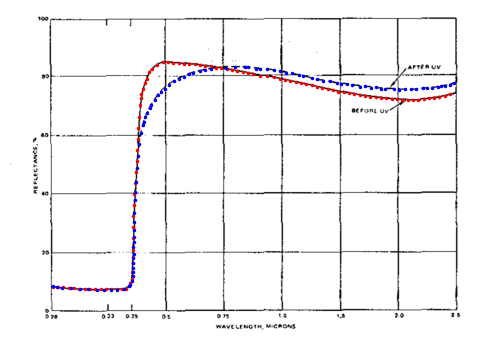

In [3]:
# Check: traced points over the original figure
img = plt.imread(D + "leggett_king_1978_fig6.png")
plt.figure(figsize=(6, 4.3)); plt.imshow(img, cmap="gray"); plt.axis("off")
for col, c in ((0, "r"), (2, "b")):
    g, r = d[:, col], d[:, col + 1]; ok = ~np.isnan(g)
    plt.plot(cal[0]["px"] + g[ok] * (cal[1]["px"] - cal[0]["px"]) / 4,
             cal[2]["py"] + (cal[3]["py"] - cal[2]["py"]) * r[ok] / 100, c + ".", ms=3)
plt.show()


In [4]:
# Rear-side gain = g0 + k*R through the ray trace's full-deck runs at 0.40 m (raytrace/ notebook): black R 0.05, white R 0.70
rt = pd.read_csv(D + "results.csv").set_index(["case", "clearance"]).gain_pct
k = (rt["full_deck_white", 0.4] - rt["full_deck_black", 0.4]) / 0.65; g0 = rt["full_deck_black", 0.4] - 0.05 * k
avg = lambda r, w: (r * w).sum() / w.sum()
uv = (wl >= 350) & (wl <= 400)
rear_uv = lambda r: (g0 + k * avg(r[uv], sun[uv])) / 0.8   # % of front UV (bifaciality 0.8)
for name, r in (("enamel", r_enamel), ("enamel, aged", r_aged), ("BaSO4 paint", r_baso4)):
    m1 = avg(r[(wl >= 400) & (wl <= 1100)], sun[(wl >= 400) & (wl <= 1100)])
    print(f"{name:13s} R(400-1100) {m1:.2f}  gain {g0 + k * avg(r, sun * sr):.1f} %  rear UV {rear_uv(r):.0f} %")


enamel        R(400-1100) 0.81  gain 17.8 %  rear UV 3 %
enamel, aged  R(400-1100) 0.78  gain 17.4 %  rear UV 2 %
BaSO4 paint   R(400-1100) 1.00  gain 22.1 %  rear UV 28 %


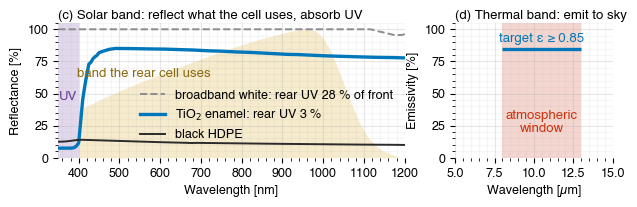

In [5]:
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams.update({"font.family": ["Helvetica", "Arial", "Liberation Sans"], "font.size": 9})
BLUE, DARK = "#0077BB", "#2b2b2b"
fig = plt.figure(figsize=(6.3, 2.2))
ax, ax2 = fig.add_axes([0.09, 0.2, 0.55, 0.613]), fig.add_axes([0.72, 0.2, 0.25, 0.613])

ax.fill_between(wl, 0, 100 * sr / sr.max(), color="#f6ebcc", lw=0)
ax.axvspan(350, 400, color="#e2d8ec", lw=0)
ax.text(375, 45, "UV", ha="center", fontsize=9.5, color="#6A3D9A", weight="bold")
ax.text(560, 63, "band the rear cell uses", ha="center", fontsize=9.5, color="#8a6a12")
ax.plot(wl, 100 * r_baso4, "--", color="#8c8c8c", lw=1.4, label=f"broadband white: rear UV {rear_uv(r_baso4):.0f} % of front")
ax.plot(wl, 100 * r_enamel, color=BLUE, lw=2.4, label=f"TiO$_2$ enamel: rear UV {rear_uv(r_enamel):.0f} %")
ax.plot(wl, 100 * r_black, color=DARK, lw=1.4, label="black HDPE")
ax.set(xlim=(350, 1200), ylim=(0, 105), xlabel="Wavelength [nm]", ylabel="Reflectance [%]")
ax.set_title("(c) Solar band: reflect what the cell uses, absorb UV", loc="left", fontsize=9.5, pad=3)
ax.legend(frameon=False, loc="lower right", bbox_to_anchor=(1, 0.04))

ax2.axvspan(8, 13, color="#f3d6cf", lw=0)
ax2.text(10.5, 20, "atmospheric\nwindow", ha="center", fontsize=9.5, color="#CC3311")
ax2.hlines(85, 8, 13, color=BLUE, lw=2.4)
ax2.text(10.5, 90, "target ε ≥ 0.85", ha="center", fontsize=9.5, color=BLUE)
ax2.set(xlim=(5, 15), ylim=(0, 105), xlabel="Wavelength [µm]", ylabel="Emissivity [%]")
ax2.set_title("(d) Thermal band: emit to sky", loc="left", fontsize=9.5, pad=3)
for a in (ax, ax2):
    [s.set_visible(False) for s in a.spines.values()]
    a.grid(alpha=0.3); a.minorticks_on(); a.grid(which="minor", alpha=0.1)
fig.savefig("fig1_cd.png", dpi=300); plt.show()
